# IPL Match Data Analysis using Python

## Project Overview
This project analyzes Indian Premier League (IPL) match data using Python.  
The main objective is to clean, explore, visualize, and extract useful insights from IPL datasets.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset Required
Place your dataset files in the same folder as this notebook:
- `matches.csv`
- `deliveries.csv` 

In [24]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load Dataset

In [25]:
# Load datasets

matches_path = "matches.csv"
deliveries_path = "deliveries.csv"

matches = pd.read_csv(matches_path)

try:
    deliveries = pd.read_csv(deliveries_path)
    deliveries_available = True
except FileNotFoundError:
    deliveries = pd.DataFrame()
    deliveries_available = False

print("Matches dataset shape:", matches.shape)
if deliveries_available:
    print("Deliveries dataset shape:", deliveries.shape)
else:
    print("Deliveries dataset not found. Player-level analysis will be skipped.")

matches.head()

Matches dataset shape: (1095, 20)
Deliveries dataset shape: (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


## 2. Basic Dataset Information

In [26]:
print("Matches Dataset Info:")
matches.info()

print("\nMissing Values in Matches Dataset:")
display(matches.isnull().sum())

print("\nDuplicate Rows in Matches Dataset:", matches.duplicated().sum())

Matches Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   objec

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


Duplicate Rows in Matches Dataset: 0


In [27]:
if deliveries_available:
    print("Deliveries Dataset Info:")
    deliveries.info()

    print("\nMissing Values in Deliveries Dataset:")
    display(deliveries.isnull().sum())

    print("\nDuplicate Rows in Deliveries Dataset:", deliveries.duplicated().sum())

Deliveries Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder      

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


Duplicate Rows in Deliveries Dataset: 0


## 3. Data Cleaning

In [28]:
# Standardize column names

matches.columns = matches.columns.str.strip().str.lower().str.replace(" ", "_")
if deliveries_available:
    deliveries.columns = deliveries.columns.str.strip().str.lower().str.replace(" ", "_")

print("Matches Columns:")
print(matches.columns.tolist())

if deliveries_available:
    print("\nDeliveries Columns:")
    print(deliveries.columns.tolist())

Matches Columns:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Deliveries Columns:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [29]:
# Create a copy for cleaning
matches_cleaned = matches.copy()

# Fill missing city values with "Unknown"
if "city" in matches_cleaned.columns:
    matches_cleaned["city"] = matches_cleaned["city"].fillna("Unknown")

# Fill missing player_of_match values
if "player_of_match" in matches_cleaned.columns:
    matches_cleaned["player_of_match"] = matches_cleaned["player_of_match"].fillna("Not Available")

# Fill missing winner values
if "winner" in matches_cleaned.columns:
    matches_cleaned["winner"] = matches_cleaned["winner"].fillna("No Result")

# Remove duplicate rows
matches_cleaned = matches_cleaned.drop_duplicates()

print("Cleaned Matches Dataset Shape:", matches_cleaned.shape)
matches_cleaned.head()

Cleaned Matches Dataset Shape: (1095, 20)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [30]:
# Clean team names if older dataset contains old franchise names

team_name_mapping = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Deccan Chargers": "Sunrisers Hyderabad",
    "Gujarat Lions": "Gujarat Titans"
}

for col in ["team1", "team2", "winner", "toss_winner"]:
    if col in matches_cleaned.columns:
        matches_cleaned[col] = matches_cleaned[col].replace(team_name_mapping)

if deliveries_available:
    deliveries_cleaned = deliveries.copy()
    for col in ["batting_team", "bowling_team"]:
        if col in deliveries_cleaned.columns:
            deliveries_cleaned[col] = deliveries_cleaned[col].replace(team_name_mapping)
else:
    deliveries_cleaned = pd.DataFrame()

matches_cleaned.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


## 4. Exploratory Data Analysis - Match Level

In [31]:
# Total matches played

total_matches = len(matches_cleaned)
print("Total IPL Matches Analyzed:", total_matches)

Total IPL Matches Analyzed: 1095


In [32]:
# Seasons covered in dataset

if "season" in matches_cleaned.columns:
    print("Seasons Covered:", sorted(matches_cleaned["season"].dropna().unique()))
    print("Total Seasons:", matches_cleaned["season"].nunique())

Seasons Covered: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']
Total Seasons: 17


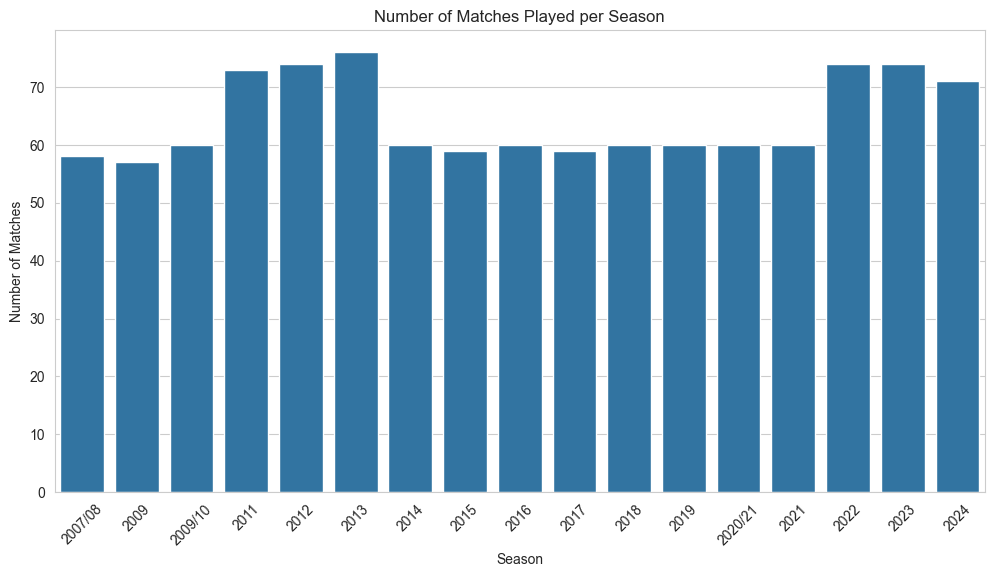

,Matches,count
0,2007/08,58
1,2009,57
2,2009/10,60
3,2011,73
4,2012,74
5,2013,76
6,2014,60
7,2015,59
8,2016,60
9,2017,59


In [33]:
# Matches played per season

if "season" in matches_cleaned.columns:
    season_matches = matches_cleaned["season"].value_counts().sort_index()

    plt.figure(figsize=(12, 6))
    sns.barplot(x=season_matches.index, y=season_matches.values)
    plt.title("Number of Matches Played per Season")
    plt.xlabel("Season")
    plt.ylabel("Number of Matches")
    plt.xticks(rotation=45)
    plt.show()

    display(season_matches.reset_index().rename(columns={"index": "Season", "season": "Matches"}))

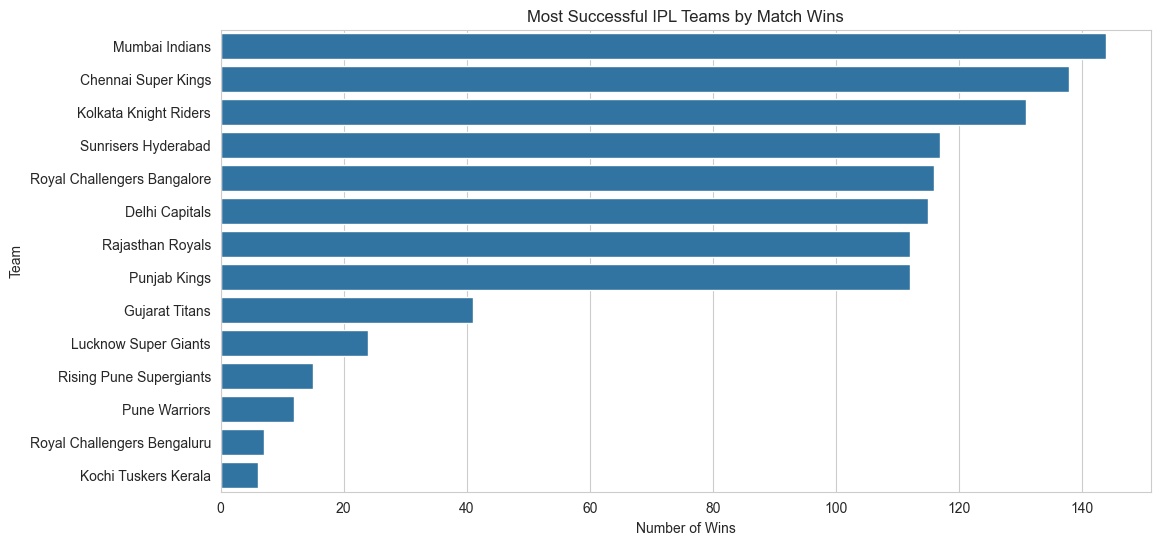

,Wins,count
0,Mumbai Indians,144
1,Chennai Super Kings,138
2,Kolkata Knight Riders,131
3,Sunrisers Hyderabad,117
4,Royal Challengers Bangalore,116
5,Delhi Capitals,115
6,Rajasthan Royals,112
7,Punjab Kings,112
8,Gujarat Titans,41
9,Lucknow Super Giants,24


In [34]:
# Most successful teams by match wins

if "winner" in matches_cleaned.columns:
    team_wins = matches_cleaned[matches_cleaned["winner"] != "No Result"]["winner"].value_counts()

    plt.figure(figsize=(12, 6))
    sns.barplot(x=team_wins.values, y=team_wins.index)
    plt.title("Most Successful IPL Teams by Match Wins")
    plt.xlabel("Number of Wins")
    plt.ylabel("Team")
    plt.show()

    display(team_wins.reset_index().rename(columns={"index": "Team", "winner": "Wins"}))

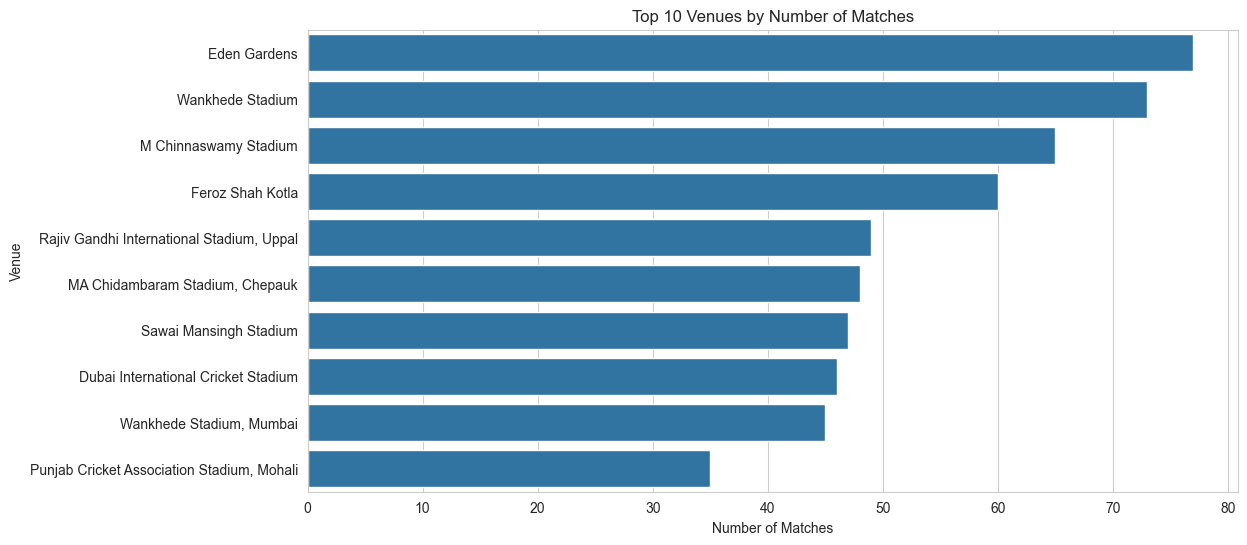

,Matches,count
0,Eden Gardens,77
1,Wankhede Stadium,73
2,M Chinnaswamy Stadium,65
3,Feroz Shah Kotla,60
4,"Rajiv Gandhi International Stadium, Uppal",49
5,"MA Chidambaram Stadium, Chepauk",48
6,Sawai Mansingh Stadium,47
7,Dubai International Cricket Stadium,46
8,"Wankhede Stadium, Mumbai",45
9,"Punjab Cricket Association Stadium, Mohali",35


In [35]:
# Top venues by number of matches

if "venue" in matches_cleaned.columns:
    top_venues = matches_cleaned["venue"].value_counts().head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_venues.values, y=top_venues.index)
    plt.title("Top 10 Venues by Number of Matches")
    plt.xlabel("Number of Matches")
    plt.ylabel("Venue")
    plt.show()

    display(top_venues.reset_index().rename(columns={"index": "Venue", "venue": "Matches"}))

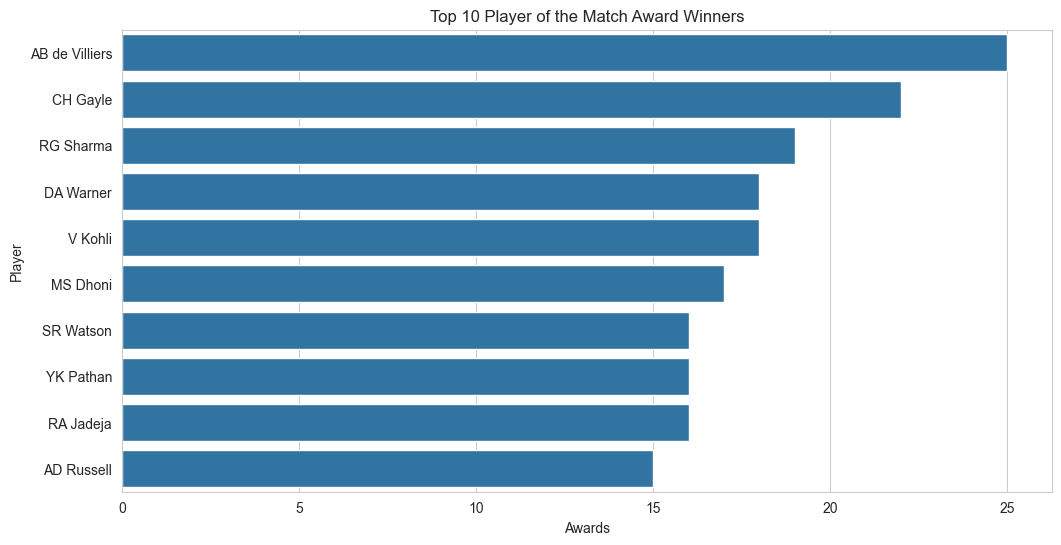

,Awards,count
0,AB de Villiers,25
1,CH Gayle,22
2,RG Sharma,19
3,DA Warner,18
4,V Kohli,18
5,MS Dhoni,17
6,SR Watson,16
7,YK Pathan,16
8,RA Jadeja,16
9,AD Russell,15


In [36]:
# Top player of the match award winners

if "player_of_match" in matches_cleaned.columns:
    top_players = matches_cleaned[matches_cleaned["player_of_match"] != "Not Available"]["player_of_match"].value_counts().head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_players.values, y=top_players.index)
    plt.title("Top 10 Player of the Match Award Winners")
    plt.xlabel("Awards")
    plt.ylabel("Player")
    plt.show()

    display(top_players.reset_index().rename(columns={"index": "Player", "player_of_match": "Awards"}))

## 5. Toss Analysis

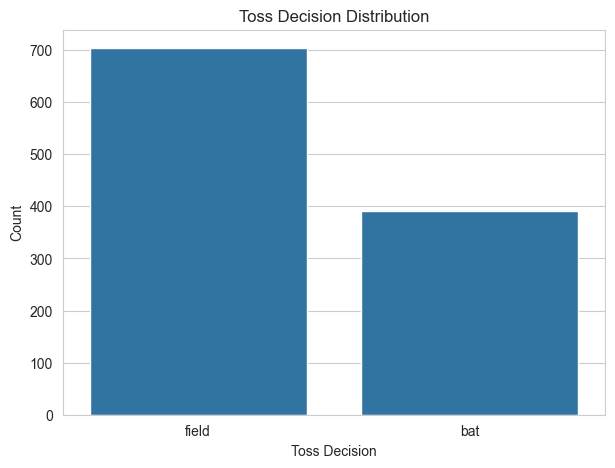

,Count,count
0,field,704
1,bat,391


In [37]:
# Toss decision distribution

if "toss_decision" in matches_cleaned.columns:
    toss_decision_count = matches_cleaned["toss_decision"].value_counts()

    plt.figure(figsize=(7, 5))
    sns.barplot(x=toss_decision_count.index, y=toss_decision_count.values)
    plt.title("Toss Decision Distribution")
    plt.xlabel("Toss Decision")
    plt.ylabel("Count")
    plt.show()

    display(toss_decision_count.reset_index().rename(columns={"index": "Toss Decision", "toss_decision": "Count"}))

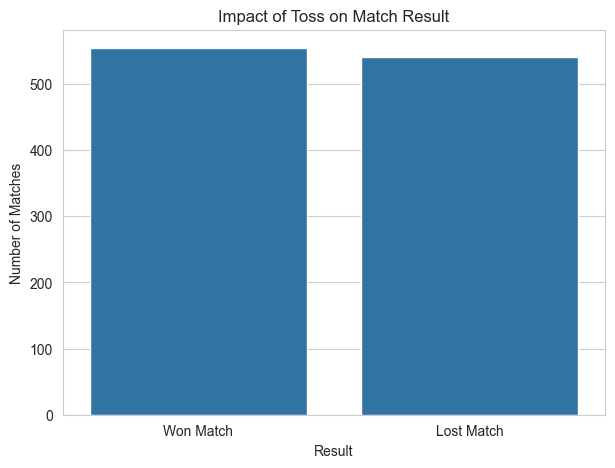

Percentage of matches won by toss-winning team: 50.59 %


In [38]:
# Toss winner vs match winner

if {"toss_winner", "winner"}.issubset(matches_cleaned.columns):
    matches_cleaned["toss_match_win"] = np.where(
        matches_cleaned["toss_winner"] == matches_cleaned["winner"],
        "Won Match",
        "Lost Match"
    )

    toss_impact = matches_cleaned["toss_match_win"].value_counts()

    plt.figure(figsize=(7, 5))
    sns.barplot(x=toss_impact.index, y=toss_impact.values)
    plt.title("Impact of Toss on Match Result")
    plt.xlabel("Result")
    plt.ylabel("Number of Matches")
    plt.show()

    toss_win_percentage = round((toss_impact.get("Won Match", 0) / toss_impact.sum()) * 100, 2)
    print("Percentage of matches won by toss-winning team:", toss_win_percentage, "%")

## 6. Batting and Bowling Analysis
This section runs only if `deliveries.csv` is available.

In [39]:
if deliveries_available:
    deliveries_cleaned.head()
else:
    print("Deliveries dataset is not available. Skipping batting and bowling analysis.")

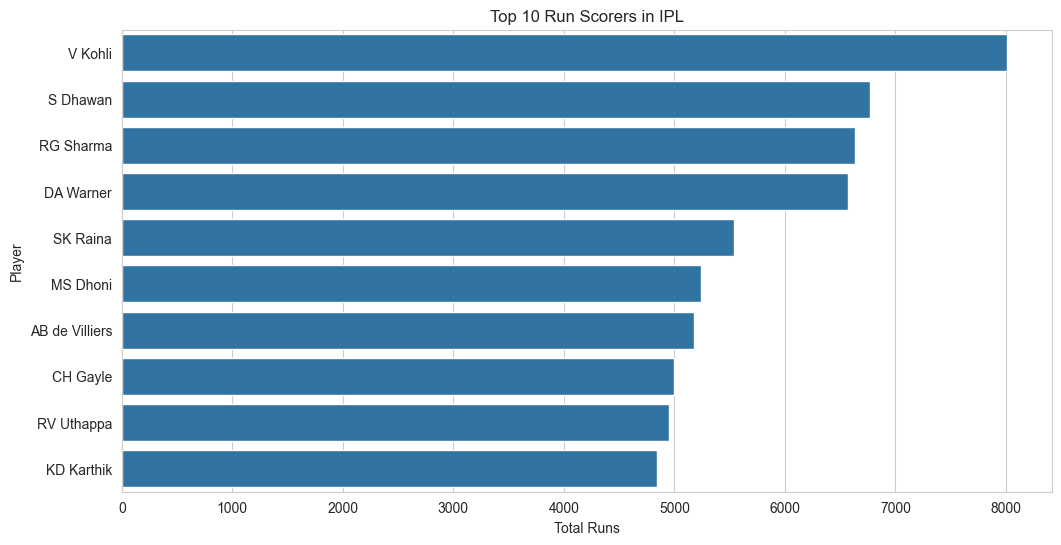

,Player,Runs
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5243
6,AB de Villiers,5181
7,CH Gayle,4997
8,RV Uthappa,4954
9,KD Karthik,4843


In [40]:
# Top run scorers

if deliveries_available and {"batter", "batsman_runs"}.issubset(deliveries_cleaned.columns):
    top_run_scorers = deliveries_cleaned.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_run_scorers.values, y=top_run_scorers.index)
    plt.title("Top 10 Run Scorers in IPL")
    plt.xlabel("Total Runs")
    plt.ylabel("Player")
    plt.show()

    display(top_run_scorers.reset_index().rename(columns={"batter": "Player", "batsman_runs": "Runs"}))
elif deliveries_available and {"batsman", "batsman_runs"}.issubset(deliveries_cleaned.columns):
    top_run_scorers = deliveries_cleaned.groupby("batsman")["batsman_runs"].sum().sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_run_scorers.values, y=top_run_scorers.index)
    plt.title("Top 10 Run Scorers in IPL")
    plt.xlabel("Total Runs")
    plt.ylabel("Player")
    plt.show()

    display(top_run_scorers.reset_index().rename(columns={"batsman": "Player", "batsman_runs": "Runs"}))

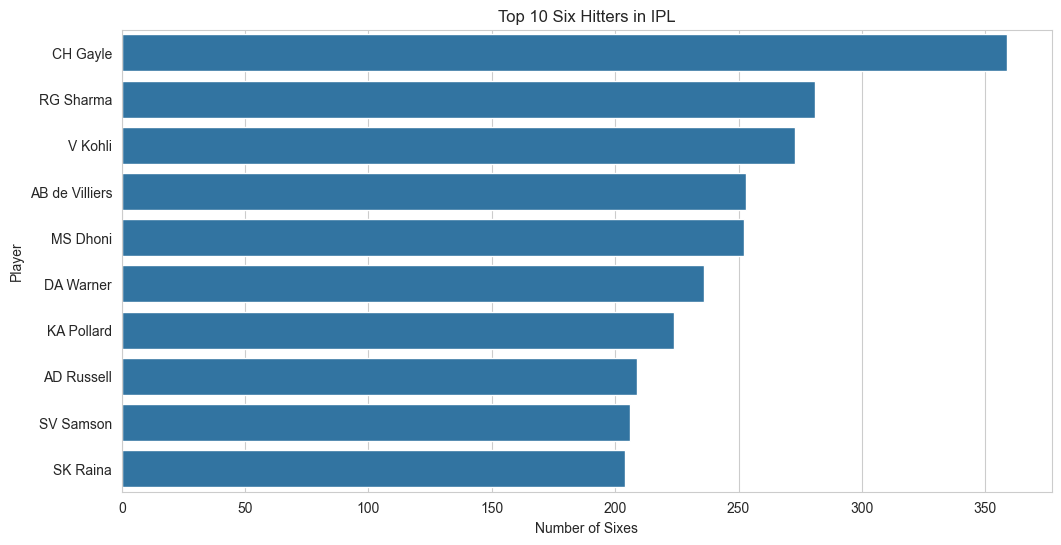

,Sixes,count
0,CH Gayle,359
1,RG Sharma,281
2,V Kohli,273
3,AB de Villiers,253
4,MS Dhoni,252
5,DA Warner,236
6,KA Pollard,224
7,AD Russell,209
8,SV Samson,206
9,SK Raina,204


In [41]:
# Most sixes

batter_col = "batter" if "batter" in deliveries_cleaned.columns else "batsman"

if deliveries_available and {batter_col, "batsman_runs"}.issubset(deliveries_cleaned.columns):
    sixes = deliveries_cleaned[deliveries_cleaned["batsman_runs"] == 6]
    top_six_hitters = sixes[batter_col].value_counts().head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_six_hitters.values, y=top_six_hitters.index)
    plt.title("Top 10 Six Hitters in IPL")
    plt.xlabel("Number of Sixes")
    plt.ylabel("Player")
    plt.show()

    display(top_six_hitters.reset_index().rename(columns={"index": "Player", batter_col: "Sixes"}))

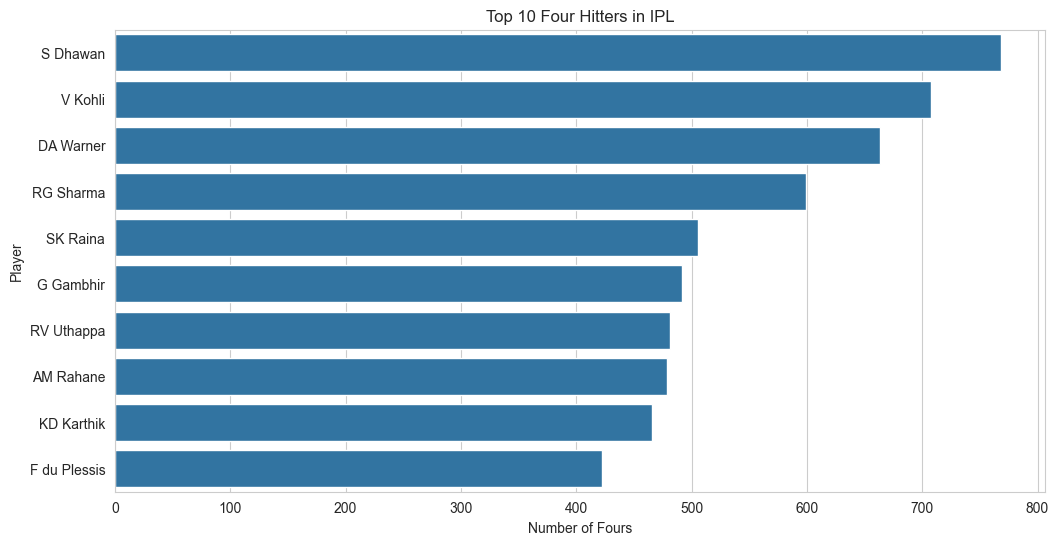

,Fours,count
0,S Dhawan,768
1,V Kohli,708
2,DA Warner,663
3,RG Sharma,599
4,SK Raina,506
5,G Gambhir,492
6,RV Uthappa,481
7,AM Rahane,479
8,KD Karthik,466
9,F du Plessis,422


In [42]:
# Most fours

if deliveries_available and {batter_col, "batsman_runs"}.issubset(deliveries_cleaned.columns):
    fours = deliveries_cleaned[deliveries_cleaned["batsman_runs"] == 4]
    top_four_hitters = fours[batter_col].value_counts().head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_four_hitters.values, y=top_four_hitters.index)
    plt.title("Top 10 Four Hitters in IPL")
    plt.xlabel("Number of Fours")
    plt.ylabel("Player")
    plt.show()

    display(top_four_hitters.reset_index().rename(columns={"index": "Player", batter_col: "Fours"}))

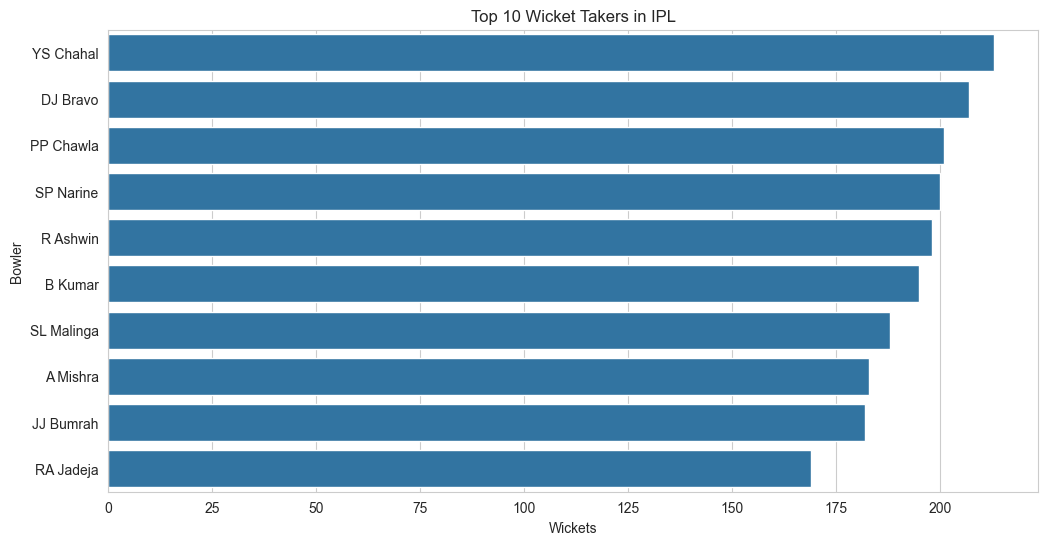

,Wickets,count
0,YS Chahal,213
1,DJ Bravo,207
2,PP Chawla,201
3,SP Narine,200
4,R Ashwin,198
5,B Kumar,195
6,SL Malinga,188
7,A Mishra,183
8,JJ Bumrah,182
9,RA Jadeja,169


In [43]:
# Leading wicket takers

if deliveries_available and {"bowler", "is_wicket"}.issubset(deliveries_cleaned.columns):
    wickets = deliveries_cleaned[deliveries_cleaned["is_wicket"] == 1]
    top_wicket_takers = wickets["bowler"].value_counts().head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_wicket_takers.values, y=top_wicket_takers.index)
    plt.title("Top 10 Wicket Takers in IPL")
    plt.xlabel("Wickets")
    plt.ylabel("Bowler")
    plt.show()

    display(top_wicket_takers.reset_index().rename(columns={"index": "Bowler", "bowler": "Wickets"}))
elif deliveries_available and {"bowler", "player_dismissed"}.issubset(deliveries_cleaned.columns):
    wickets = deliveries_cleaned[deliveries_cleaned["player_dismissed"].notna()]
    top_wicket_takers = wickets["bowler"].value_counts().head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_wicket_takers.values, y=top_wicket_takers.index)
    plt.title("Top 10 Wicket Takers in IPL")
    plt.xlabel("Wickets")
    plt.ylabel("Bowler")
    plt.show()

    display(top_wicket_takers.reset_index().rename(columns={"index": "Bowler", "bowler": "Wickets"}))

## 7. Team Performance Analysis

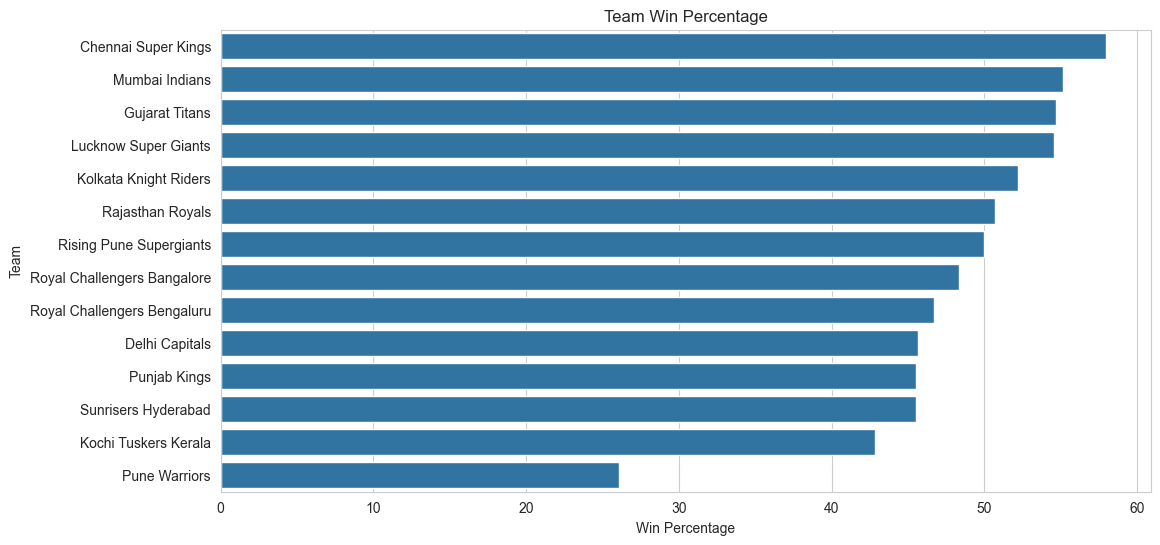

,Team,count
0,Chennai Super Kings,57.983193
1,Mumbai Indians,55.172414
2,Gujarat Titans,54.666667
3,Lucknow Super Giants,54.545455
4,Kolkata Knight Riders,52.191235
5,Rajasthan Royals,50.678733
6,Rising Pune Supergiants,50.000000
7,Royal Challengers Bangalore,48.333333
8,Royal Challengers Bengaluru,46.666667
9,Delhi Capitals,45.634921


In [44]:
# Team win percentage

if {"team1", "team2", "winner"}.issubset(matches_cleaned.columns):
    team_matches = pd.concat([matches_cleaned["team1"], matches_cleaned["team2"]]).value_counts()
    team_wins = matches_cleaned[matches_cleaned["winner"] != "No Result"]["winner"].value_counts()

    win_percentage = ((team_wins / team_matches) * 100).sort_values(ascending=False).dropna()

    plt.figure(figsize=(12, 6))
    sns.barplot(x=win_percentage.values, y=win_percentage.index)
    plt.title("Team Win Percentage")
    plt.xlabel("Win Percentage")
    plt.ylabel("Team")
    plt.show()

    display(win_percentage.reset_index().rename(columns={"index": "Team", 0: "Win Percentage"}))

In [45]:
# Team performance summary table

if {"team1", "team2", "winner"}.issubset(matches_cleaned.columns):
    team_summary = pd.DataFrame({
        "Matches Played": team_matches,
        "Matches Won": team_wins
    }).fillna(0)

    team_summary["Matches Won"] = team_summary["Matches Won"].astype(int)
    team_summary["Win Percentage"] = round((team_summary["Matches Won"] / team_summary["Matches Played"]) * 100, 2)
    team_summary = team_summary.sort_values(by="Win Percentage", ascending=False)

    display(team_summary)

,Matches Played,Matches Won,Win Percentage
Chennai Super Kings,238,138,57.98
Mumbai Indians,261,144,55.17
Gujarat Titans,75,41,54.67
Lucknow Super Giants,44,24,54.55
Kolkata Knight Riders,251,131,52.19
Rajasthan Royals,221,112,50.68
Rising Pune Supergiants,30,15,50.00
Royal Challengers Bangalore,240,116,48.33
Royal Challengers Bengaluru,15,7,46.67
Delhi Capitals,252,115,45.63


## 8. Season-wise Winning Teams

In [46]:
if {"season", "winner"}.issubset(matches_cleaned.columns):
    season_team_wins = matches_cleaned.groupby(["season", "winner"]).size().reset_index(name="wins")
    top_team_each_season = season_team_wins.sort_values(["season", "wins"], ascending=[True, False]).groupby("season").head(1)

    display(top_team_each_season.rename(columns={"season": "Season", "winner": "Team", "wins": "Wins"}))

,Season,Team,Wins
5,2007/08,Rajasthan Royals,13
9,2009,Delhi Capitals,10
19,2009/10,Mumbai Indians,11
24,2011,Chennai Super Kings,11
37,2012,Kolkata Knight Riders,12
47,2013,Mumbai Indians,13
57,2014,Punjab Kings,12
61,2015,Chennai Super Kings,10
77,2016,Sunrisers Hyderabad,11
81,2017,Mumbai Indians,12


## 9. Correlation Analysis

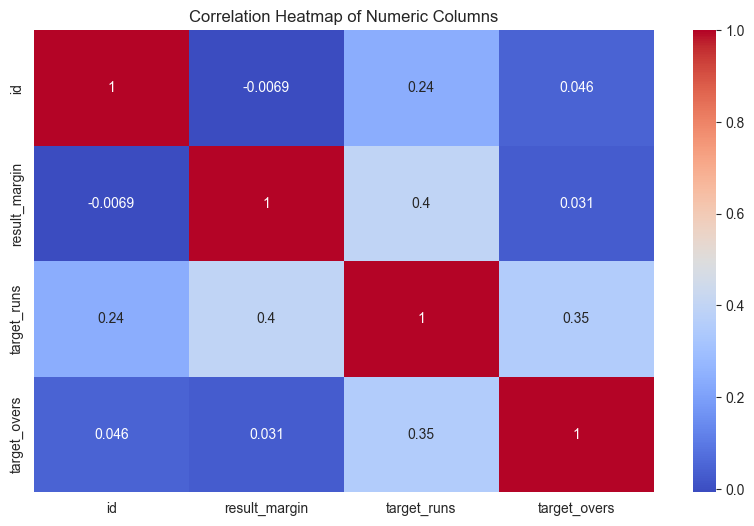

In [47]:
# Numeric correlation heatmap

numeric_cols = matches_cleaned.select_dtypes(include=np.number)

if numeric_cols.shape[1] > 1:
    plt.figure(figsize=(10, 6))
    sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap of Numeric Columns")
    plt.show()
else:
    print("Not enough numeric columns available for correlation analysis.")

## 10. Key Insights

In [48]:
insights = []

if "winner" in matches_cleaned.columns:
    best_team = matches_cleaned[matches_cleaned["winner"] != "No Result"]["winner"].value_counts().idxmax()
    insights.append(f"The most successful team by total wins is {best_team}.")

if "player_of_match" in matches_cleaned.columns:
    best_player = matches_cleaned[matches_cleaned["player_of_match"] != "Not Available"]["player_of_match"].value_counts().idxmax()
    insights.append(f"The player with the most Player of the Match awards is {best_player}.")

if "venue" in matches_cleaned.columns:
    most_used_venue = matches_cleaned["venue"].value_counts().idxmax()
    insights.append(f"The venue that hosted the highest number of matches is {most_used_venue}.")

if "toss_match_win" in matches_cleaned.columns:
    insights.append(f"The toss-winning team won approximately {toss_win_percentage}% of matches.")

if deliveries_available and "top_run_scorers" in globals():
    insights.append(f"The highest run scorer in the dataset is {top_run_scorers.index[0]}.")

print("Key Insights:")
for i, insight in enumerate(insights, start=1):
    print(f"{i}. {insight}")

Key Insights:
1. The most successful team by total wins is Mumbai Indians.
2. The player with the most Player of the Match awards is AB de Villiers.
3. The venue that hosted the highest number of matches is Eden Gardens.
4. The toss-winning team won approximately 50.59% of matches.
5. The highest run scorer in the dataset is V Kohli.


## 11. Conclusion

This IPL Data Analysis project helped in understanding:
- Team performance trends
- Player performance statistics
- Toss impact on match results
- Venue-wise match distribution
- Batting and bowling performance patterns

This project demonstrates skills in:
- Data cleaning
- Exploratory Data Analysis
- Data visualization
- Statistical analysis
- Insight generation using Python